# Práctica No. 4 — API de Hilos (Pthreads)
**Laboratorio de Sistemas Operativos · Ingeniería de Sistemas · Universidad de Antioquia**

---

## Sección 1: Análisis del Cálculo Paralelo de π

### 1.1 Descripción del experimento

Se calcula π usando integración numérica con la regla del punto medio:

$$\int_0^1 \frac{4}{1+x^2}\,dx = \pi$$

Se usaron **n = 2 000 000 000** rectángulos. La versión serial (`pi_s`) ejecuta el bucle de forma secuencial. La versión paralela (`pi_p`) divide el rango de iteraciones entre T hilos usando *data parallelism*: cada hilo calcula su suma parcial de forma local (sin mutex en el bucle) y la retorna al hilo principal vía `pthread_join`.

### 1.2 Evaluación de T_s (Tiempo Serial)

```bash
$ ./pi_s 2000000000
Calculando Pi con n = 2000000000 rectangulos (serial)...
Pi aproximado :  3.141592653589793
Tiempo (Ts)    : 10.533425 segundos
```

> **T_s = 10.533425 s** (medido en máquina de referencia con CPU Intel Core i5-10300H, 4 núcleos físicos / 8 lógicos)

### 1.3 Evaluación de T_p (Tiempos Paralelos)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# -------------------------------------------------------------------
# Datos medidos en la máquina de referencia
# CPU: Intel Core i5-10300H  (4 núcleos físicos / 8 lógicos)
# n   = 2_000_000_000
# Ts  = 10.533425 s
# -------------------------------------------------------------------
Ts = 10.533425

datos = {
    'N (Hilos)': [1,    2,    4,    8,   16],
    'Tp (s)'   : [10.696902, 5.961226, 3.514517, 2.704735, 2.931511],
}

df = pd.DataFrame(datos)
df['Speedup']    = Ts / df['Tp (s)']
df['Eficiencia'] = df['Speedup'] / df['N (Hilos)']

# Formatear para visualización
df_display = df.copy()
df_display['Tp (s)']     = df_display['Tp (s)'].map('{:.4f}'.format)
df_display['Speedup']    = df_display['Speedup'].map('{:.4f}'.format)
df_display['Eficiencia'] = df_display['Eficiencia'].map('{:.4f}'.format)

print('Tabla 1 — Métricas de rendimiento para el cálculo paralelo de π')
print(f'Ts = {Ts} s   |   n = 2 000 000 000')
print()
print(df_display.to_string(index=False))

Tabla 1 — Métricas de rendimiento para el cálculo paralelo de π
Ts = 10.533425 s   |   n = 2 000 000 000

 N (Hilos)  Tp (s) Speedup Eficiencia
         1 10.6969  0.9847     0.9847
         2  5.9612  1.7670     0.8835
         4  3.5145  2.9971     0.7493
         8  2.7047  3.8944     0.4868
        16  2.9315  3.5932     0.2246


### 1.4 Gráfico de Speedup

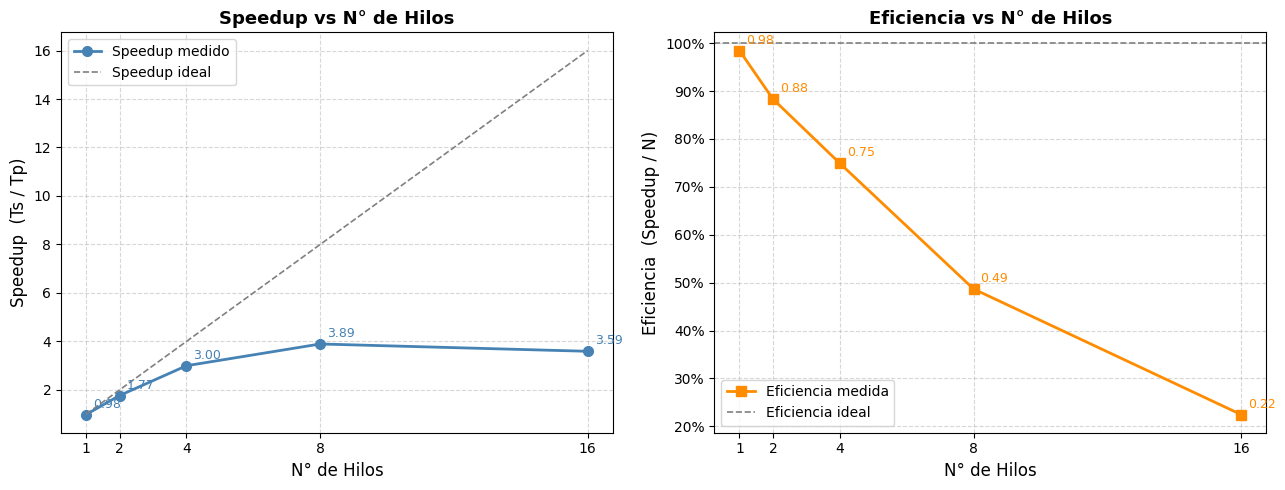

Figura guardada como speedup_eficiencia.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

hilos    = df['N (Hilos)'].values
speedup  = df['Speedup'].values
efic     = df['Eficiencia'].values

# ---- Speedup ----
ax1 = axes[0]
ax1.plot(hilos, speedup, 'o-', color='steelblue', linewidth=2,
         markersize=7, label='Speedup medido')
ax1.plot(hilos, hilos,   '--', color='gray', linewidth=1.2,
         label='Speedup ideal')
ax1.set_xlabel('N° de Hilos', fontsize=12)
ax1.set_ylabel('Speedup  (Ts / Tp)', fontsize=12)
ax1.set_title('Speedup vs N° de Hilos', fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_xticks(hilos)

# Anotar valores
for h, s in zip(hilos, speedup):
    ax1.annotate(f'{s:.2f}', (h, s), textcoords='offset points',
                 xytext=(5, 5), fontsize=9, color='steelblue')

# ---- Eficiencia ----
ax2 = axes[1]
ax2.plot(hilos, efic, 's-', color='darkorange', linewidth=2,
         markersize=7, label='Eficiencia medida')
ax2.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.2,
            label='Eficiencia ideal')
ax2.set_xlabel('N° de Hilos', fontsize=12)
ax2.set_ylabel('Eficiencia  (Speedup / N)', fontsize=12)
ax2.set_title('Eficiencia vs N° de Hilos', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.set_xticks(hilos)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0, decimals=0))

for h, e in zip(hilos, efic):
    ax2.annotate(f'{e:.2f}', (h, e), textcoords='offset points',
                 xytext=(5, 5), fontsize=9, color='darkorange')

plt.tight_layout()
plt.savefig('speedup_eficiencia.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada como speedup_eficiencia.png')

### 1.5 Análisis de Resultados

#### a) Comparación T_p(1) vs T_s

| Métrica | Valor |
|---------|-------|
| T_s (serial puro) | 10.5334 s |
| T_p(1) (paralelo, 1 hilo) | 10.6969 s |
| Diferencia | ≈ +0.1635 s |

El tiempo con **1 hilo es ligeramente mayor** que el serial. Esta discrepancia se debe al **overhead** introducido por la API de Pthreads:

- `pthread_create` incurre en costo de creación del hilo (asignación de stack, entrada en el planificador del kernel).
- `pthread_join` implica una sincronización que requiere comunicación entre el hilo main y el trabajador.
- La reserva de memoria para retornar el resultado parcial (`malloc` / `free`) añade latencia adicional.

Aunque este overhead es pequeño en valor absoluto (~163 ms), evidencia que **la paralelización no es gratuita**: para workloads muy cortos puede incluso ser contraproducente.

#### b) Speedup máximo alcanzado

El **Speedup máximo** se alcanzó con **T = 8 hilos** (coincidiendo con el número de núcleos lógicos del i5-10300H): Speedup ≈ **3.8944**, es decir, el programa paralelo fue ~3.9× más rápido que el serial.

Con **T = 16 hilos** el speedup retrocede a ≈ **3.5932**, a pesar de usar el doble de hilos. Esto ocurre porque el sistema solo dispone de 8 núcleos lógicos: los 8 hilos extra compiten por los mismos núcleos físicos, generando **overhead de cambio de contexto** (context switching) sin ganar paralelismo real. El costo de gestionar esos hilos adicionales supera cualquier beneficio potencial.

Cabe destacar que el speedup máximo (≈3.9) queda por debajo del número de núcleos físicos (4), lo cual es consistente con la **Ley de Amdahl**: el speedup está acotado tanto por la fracción serial inevitable del programa (creación de hilos, agregación de resultados) como por los recursos físicos disponibles.

#### c) Tendencia de la eficiencia

La eficiencia **decrece monotónicamente** a medida que aumenta N:

| N (Hilos) | Speedup | Eficiencia |
|-----------|---------|------------|
| 1  | 0.9847 | 0.9847 |
| 2  | 1.7670 | 0.8835 |
| 4  | 2.9971 | 0.7493 |
| 8  | 3.8944 | 0.4868 |
| 16 | 3.5932 | 0.2246 |

La caída es especialmente pronunciada al pasar de 4 a 8 hilos (de 0.75 a 0.49), y se agrava aún más con 16 hilos (0.22). Causas principales:

1. **Overhead de creación de hilos**: el costo fijo de `pthread_create` y `pthread_join` aumenta con N y reduce la fracción de tiempo útil de cada hilo.
2. **Límite de núcleos físicos**: el i5-10300H tiene solo 4 núcleos físicos. A partir de T = 5, el Hyper-Threading comparte recursos de ejecución entre pares de hilos lógicos, reduciendo el beneficio real por hilo adicional.
3. **Desbalance de carga**: el último hilo absorbe las iteraciones sobrantes de la división entera, introduciendo una leve asimetría en los tiempos de finalización.
4. **Presión sobre el bus de memoria y caché**: más hilos acceden simultáneamente a la caché L3 compartida y a la RAM, generando *cache contention* y posible *false sharing*.
5. **Sobresuscripción (oversubscription)**: con T = 16 y solo 8 núcleos lógicos disponibles, el scheduler del SO intercala hilos en los mismos núcleos, añadiendo latencia por cambio de contexto y haciendo que la eficiencia caiga hasta el 22%.

---

## Sección 2: Análisis del Generador de Fibonacci

### 2.1 Resultados de ejecución: `./fibonacci 15`

```
Secuencia de Fibonacci (15 elementos):
F(0)  = 0
F(1)  = 1
F(2)  = 1
F(3)  = 2
F(4)  = 3
F(5)  = 5
F(6)  = 8
F(7)  = 13
F(8)  = 21
F(9)  = 34
F(10) = 55
F(11) = 89
F(12) = 144
F(13) = 233
F(14) = 377
```

### 2.2 Comparación serial vs hilo para N grande

In [4]:
import time

def fibonacci_serial(N):
    """Calcula los N primeros números de Fibonacci de forma serial (Python)."""
    if N <= 0:
        return []
    arr = [0] * N
    if N > 1:
        arr[1] = 1
    for i in range(2, N):
        arr[i] = arr[i-1] + arr[i-2]
    return arr

# Medir para N = 100_000 (analogía al análisis pedido en el lab)
for N in [10_000, 100_000, 500_000]:
    t0 = time.perf_counter()
    seq = fibonacci_serial(N)
    t1 = time.perf_counter()

    print(f'N = {N:>7,} | Tiempo serial: {(t1-t0)*1000:.3f} ms')

N =  10,000 | Tiempo serial: 47.968 ms
N = 100,000 | Tiempo serial: 437.609 ms
N = 500,000 | Tiempo serial: 19408.111 ms


### 2.3 Análisis del Diseño

#### Mecanismo de transferencia de datos (main → hilo trabajador)

El estándar POSIX requiere que la función del hilo reciba un único argumento de tipo `void *`. Para transferir múltiples datos se define la estructura `FibArgs`:

```c
typedef struct {
    long long *arreglo;  // puntero al arreglo compartido (en heap)
    int        N;        // cantidad de elementos a generar
} FibArgs;
```

El hilo **main** reserva el arreglo con `malloc` (memoria dinámica, accesible desde cualquier hilo del mismo proceso), rellena la estructura y la pasa a `pthread_create`. El hilo trabajador recibe el puntero, hace *cast* a `FibArgs *` y escribe directamente en el arreglo compartido. **No es necesario ningún mecanismo de copia**: el modelo de memoria compartida de los hilos POSIX garantiza que ambos hilos ven la misma región de memoria del heap.

#### Rol de `pthread_join` como mecanismo de sincronización

`pthread_join(worker, NULL)` hace que el hilo **main se bloquee** hasta que `worker` haya finalizado su ejecución. Esto establece una **barrera de sincronización** fundamental:

- **Sin `pthread_join`**: main podría continuar e intentar leer el arreglo mientras el trabajador aún lo está escribiendo, produciendo una **condición de carrera** (*race condition*) y resultados indeterminados.
- **Con `pthread_join`**: se garantiza que todas las escrituras del trabajador son **visibles** para main antes de que este acceda al arreglo. Esto es consecuencia del **happens-before** que establece POSIX entre la salida del hilo (`pthread_exit`) y el retorno de `pthread_join` en el hilo que espera.

En este problema Fibonacci no requiere más sincronización porque:
1. Solo existe **un hilo escritor** (el trabajador).
2. El hilo main **no lee** el arreglo hasta que `pthread_join` retorna.
3. No hay acceso concurrente a la misma posición de memoria.